# Notebook 4: Lattice fermions

This tutorial builds upon that written by Giuseppe Carleo (Computational Quantum Science Lab - EPFL) for the official NetKet documentation.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Z-Denis/cecam-nqs/blob/main/notebooks/04_lattice_fermions.ipynb)

If you are running locally, start JupyterLab with:

```bash
uv run jupyter lab
```

In [29]:
# IF AND ONLY IF you are running this notebook on Google Colab:

# On a CPU runtime, uncomment and run:
# %pip uninstall -y jax jaxlib jax-cuda12-plugin jax-cuda12-pjrt
# %pip install -q "jax==0.10.1" "jaxlib==0.10.1"
# %pip install -q git+https://github.com/Z-Denis/cecam-nqs.git

# On a T4 GPU runtime, uncomment and run:
# %pip install -q "jax[cuda12]==0.10.1"
# %pip install -q git+https://github.com/Z-Denis/cecam-nqs.git

In this tutorial, we will introduce you to studying fermionic quantum many-body systems in second quantisation using NetKet. While we will assume that you are familiar with the formalism of second quantisation, we will first go through the subtle implications of the fermionic quantum statistics in the sign structure of the many-fermion wave function. We will introduce fermionic operators and how to work with them in NetKet. We will then physically motivate and implement three different wave functions: a Slater determinant wavefunction, a neural Jastrow-Slater state, and a Slater backflow neural wavefunction. In the following, we will focus on a Hamiltonian of spinless fermions in two dimensions.

# Second quantisation in practice: canonical ordering

In _first quantisation_, the state of a quantum system consisting of $N_f$ fermions is described by a wave function over $N_f$ particle coordinates $(R_1,\ldots,R_{N_f}) \in \mathbb{K}^{N_f}$, where $\mathbb{K}$ may be for instance $[0, L]^d$, in the case of particles in a $d$-dimensional box; or $\lbrace 0,\ldots, L^d - 1\rbrace$ in the case of interest here, where each particle's coordinate corresponds to a linear index of a lattice site. In this picture, operators act on these coordinates directly, and the wave function _must_ be antisymmetric with respect to particle exchange:

$$
\psi(\ldots,R_j,\ldots,R_i,\ldots) \overset{!}{=} -\psi(\ldots,R_i,\ldots,R_j,\ldots),\quad \forall i, j \in 1,\ldots,N_f.
$$

In _second quantisation_, we instead describe quantum states in terms of occupation numbers of a fixed basis of $N_o$ single-particle states that we shall henceforth refer to as modes or orbitals. In this formalism, the wave function is expressed over a set of occupation numbers $(n_1,\ldots,n_{N_o}) \in \lbrace 0, 1\rbrace^{N_o}$, with $\sum_{i}n_i = N_f$. This approach is especially well suited to systems with variable particle number, such as many-body fermionic systems on a lattice. We introduce creation ($\hat{c}_i^\dagger$) and annihilation ($\hat{c}_i$) operators that act on the above Fock space. These operators obey canonical anticommutation relations:

$$
\lbrace\hat{c}_i, \hat{c}_j^\dagger\rbrace = \delta_{ij},\quad \lbrace\hat{c}_i, \hat{c}_j\rbrace = \lbrace\hat{c}_i^\dagger, \hat{c}_j^\dagger\rbrace = 0.
$$

In this picture, the fermionic antisymmetrisation of the wave function may not seem completely manifest a priori. Indeed, occupation factors are _symmetric_ under particle exchange. However, the amplitudes of the wave function _do_ exhibit a particular sign structure. This originates from the way the Fock space is constructed.

Naively, any odd permutation of some first-quantised configuration $(R_1,\ldots,R_{N_f})$ would result in the same second-quantised configuration $(n_1,\ldots,n_{N_o})$. To lift this ambiguity, the Fock basis is built from a reference vacuum state $\lvert 0\rangle$ (with all modes unoccupied) by applying creation operators in a fixed order:

$$
|n_1, n_2, \dots, n_{N_o}\rangle = (\hat{c}_1^\dagger)^{n_1} (\hat{c}_2^\dagger)^{n_2} \cdots (\hat{c}_{N_o}^\dagger)^{n_{N_o}} |0\rangle \overset{!}{=} \hat{c}_{R_1}^\dagger \hat{c}_{R_2}^\dagger \cdots \hat{c}_{R_{N_f}}^\dagger |0\rangle.
$$

This choice is known as the _canonical ordering_. It fixes the sign conventions when manipulating fermionic states and operators: permuting fermionic operators generally introduces a minus sign due to their anticommutation.  Maintaining a consistent ordering is therefore crucial in simulations. When an operator acts on a basis state, creation and annihilation operators must generally be rearranged into canonical order. Each exchange produces a minus sign, so matrix elements acquire a phase determined by the parity of the corresponding permutation. Consider for example the hopping operator $\hat{c}_3^\dagger \hat{c}_1$ acting onto a Fock state,

$$
\hat{c}_3^\dagger \hat{c}_1 \ket{1,1,0,0} = \hat{c}_3^\dagger \hat{c}_1 \hat{c}_1^\dagger \hat{c}_2^\dagger \ket{0} =
\hat{c}_3^\dagger \hat{c}_2^\dagger \ket{0} = - \hat{c}_2^\dagger \hat{c}_3^\dagger \ket{0} = -\ket{0,1,1,0} .
$$

The minus sign appears when restoring the creation operators to canonical order. This is the elementary origin of the fermionic sign structure.

Fortunately for you, most of this logic is already handled by NetKet!

## Fermionic operators in NetKet

Fermionic operators are fundamental to describing quantum systems with fermions. NetKet provides these operators directly via the `netket.operator.fermion` module. Let's start by setting up the necessary environment and defining our quantum system.

We will work with a Hamiltonian of spinless fermions on a two-dimensional lattice:

$$
\hat{H} = -t \sum_{\langle i,j \rangle } \left( \hat{c}^{\dagger}_i \hat{c}_j + \hat{c}^{\dagger}_j \hat{c}_i \right ) + V \sum_{\langle i,j \rangle } \hat{n}_i \hat{n}_j
$$

Here, $\langle i,j \rangle $ denotes nearest-neighbors on a square lattice of $N=L\times L$ sites, $\hat{c}_i$ $(\hat{c}^{\dagger}_i)$ are destruction (creation) fermionic operators on site $i$, whereas $\hat{n}_i=\hat{c}^{\dagger}_i \hat{c}_i$ are density operators. Although this is not the case in general, note that, in this example, the modes/orbitals happen to correspond exactly to the particles' positions (which can be a source of confusion).

## Defining the lattice and the Hilbert space

We start by defining a small $4\times 4$ square lattice with periodic boundary conditions:

In [1]:
import netket as nk
L = 4  # Side of the square
graph = nk.graph.Square(L)
N = graph.n_nodes

∣NK⟩ Tip: You can plot data with JsonLog.data['Energy'][:-30].plot().

The last variable contains the total number of sites (modes/orbitals) on the lattice.

We now define also the Hilbert space associated with a system of $N_{\mathrm{f}}$ spinless fermions:

In [2]:
N_f = 5

hi = nk.hilbert.SpinOrbitalFermions(N, s=None, n_fermions=N_f)

Notice that in the definition we have specified `s=None`, meaning that these fermions do not carry spin. If you wanted to work with spinful fermions, you would need to specify for example `s=1/2`.

## Fermionic operators and Hamiltonian

To describe the Hamiltonian of our quantum system, we need to work with the fermionic operators associated with the Hilbert space defined above. These operators include creation (`cdag`), annihilation (`c`), and number (`nc`) operators. We will use these operators to build our Hamiltonian.

In [3]:
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc

With these operators, we can now construct the Hamiltonian for our system. In this example, we have a tight-binding hopping term proportional to $t$ and a density-density interaction term proportional to $V$. We can easily define the Hamiltonian by adding terms one by one looping over the edges of the lattice:


In [4]:
t = 1.0
V = 4.0

H = 0.0
for (i, j) in graph.edges():
    H -= t * (cdag(hi,i) @ c(hi,j) + cdag(hi,j) @ c(hi,i))
    H += V * nc(hi,i) @ nc(hi,j)

As you already know from previous tutorials, in variational Monte Carlo, the expectation value of the Hamiltonian, as for that of any operator, may be obtained from a local estimator

$$
  E_\text{loc}(n_1,\ldots, n_N) = \sum_{n'_1,\ldots, n'_N} \langle n_1,\ldots, n_N|\hat{H}|n'_1,\ldots, n'_N\rangle \frac{\psi(n'_1,\ldots, n'_N)}{\psi(n_1,\ldots, n_N)}.
$$

While the connected elements $(n'_1,\ldots, n'_N)$ are easy to compute a priori, the off-diagonal matrix elements involve computing the sign of the permutation needed to bring $\langle n_1,\ldots, n_N|\hat{c}_i^\dagger\hat{c}_j|n'_1,\ldots, n'_N\rangle = \langle 0\rvert \hat{c}_N^{n_N} \cdots \hat{c}_2^{n_2} \hat{c}_1^{n_1} \cdot \hat{c}_i^\dagger\hat{c}_j \cdot  (\hat{c}_1^\dagger)^{n'_1} (\hat{c}_2^\dagger)^{n'_2} \cdots (\hat{c}_N^\dagger)^{n'_{N}} |0\rangle$ into canonical ordering. As mentioned earlier, this is carried out automatically in NetKet.

## Exact diagonalisation

Since the system is relatively small, the Hilbert space is also not too big, and we can still use exact diagonalization to compute the exact ground state energy. This is achieved by first converting the Hamiltonian to a sparse matrix, and then diagonalizing it with scipy:

In [5]:
# Convert the Hamiltonian to a sparse matrix
sp_h = H.to_sparse()

In [6]:
sp_h.shape

(4368, 4368)

In [7]:
from scipy.sparse.linalg import eigsh

eig_vals, eig_vecs = eigsh(sp_h, k=2, which="SA")

E_gs = eig_vals[0]

print("Exact ground-state energy:", E_gs)

Exact ground-state energy: -6.859013554319592


## Slater determinant

In the weakly interacting regime ($V/t \sim 0$), the Hamiltonian of the system is close to quadratic. Such a Hamiltonian can be brought into a diagonal form $\hat{H}_0 = \sum_\alpha \epsilon_\alpha \hat{\phi}_\alpha^\dagger\hat{\phi}_\alpha$, where $\phi^{\dagger}_{\alpha}$ corresponds to the creation operator in a single-particle orbital. This is in general a linear combination of the original creation operators:

$$
\hat{\phi}^{\dagger}_{\alpha} = \sum_i M_{i,\alpha} \hat{c}^{\dagger}_i,
$$

where the rectangular ($N\times N_{\mathrm{f}}$, where $N$ is the number of sites/orbitals and $N_{\mathrm{f}}$ the number of fermions) matrix $M$ can be obtained analytically for any quadratic Hamiltonian. Then, the ground state can be obtained by filling up the $N_f$ lowest-energy orbitals, formally

$$
|\Phi_s\rangle = \prod_{\alpha=1}^{N_{\mathrm{f}}} \hat{\phi}^{\dagger}_{\alpha} |0\rangle.
$$

# <Blackboard: comment on the Brillouin zone and closed shells>

Within a mean-field description, one may assume that the system is approximatelly described by an effective parent Hamiltonian of quadratic form. Hence, one may attempt to obtain a faithful variational ground state of the many-body problem by allowing the elements of the matrix $M$ to be now _free_ variational parameters.

We now need to find a way to evaluate the amplitudes of the wave function in Fock space:

$$
\Phi_s({\bf n}) := \langle n_1,\dots,n_N |\Phi_s\rangle
= \langle 0\rvert \hat{c}_{R_{N_f}} \cdots \hat{c}_{R_1} \prod_\alpha\sum_i M_{i, \alpha} \hat{c}^{\dagger}_i\lvert 0\rangle\\
\overset{!}{=} \langle 0\rvert \hat{c}_{R_{N_f}} \cdots \hat{c}_{R_1} \Bigl[\sum_\sigma \mathrm{sgn}(\sigma)\prod_{\alpha=1}^{N_f}M_{\sigma(R_{\alpha}), \alpha}\Bigr]\hat{c}_{R_1}^\dagger\cdots \hat{c}_{R_{N_f}}^\dagger\lvert 0\rangle\\
= \mathrm{det}\left\{A({\bf n})\right\},
$$

where $A({\bf n})$ is the $N_{\mathrm{f}}\times N_{\mathrm{f}}$ matrix with elements given by

$$
A({\bf n})_{\alpha,\beta} = M_{R_{\alpha}, \beta},
$$

and where $R_{\alpha}$ denotes the index of the $\alpha$-th occupied site (non-zero $n_i$) in ${\bf n}=(n_1,\dots,n_N)$.
This can also be interepted as selecting $N_\mathrm{f}$ rows of the matrix $M$ corresponding to the $N_\mathrm{f}$ occupied orbitals, i.e. masking rows in coding language.
For more details see Chapter 5 of Reference [1].


To write down these variational amplitudes, we start by defining a convenience function to compute the logarithm of the determinant of a matrix, in the complex domain, and using jax:

In [8]:
import jax
import jax.numpy as jnp

# Note: This function can also be found inside of netket, in `nk.jax.logdet_cmplx`, but we implement it here
# for pedagogical purposes.
def _logdet_cmplx(A):
    sign, logabsdet = jnp.linalg.slogdet(A)
    return logabsdet.astype(complex) + jnp.log(sign.astype(complex))

# <Blackboard: comment on complex logarithms>

Next, we define a wave function using Flax. As you might have seen also in other tutorials, NetKet defines the logarithm of the wave function amplitudes, mostly to avoid overflow/underflow when computing relevant quantities. The model wave function is then:

In [9]:
import flax.linen as nn
from netket.utils.types import NNInitFunc
from netket.nn.masked_linear import default_kernel_init
from typing import Any, Callable, Sequence
from functools import partial
DType = Any

class LogSlaterDeterminant(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    kernel_init: NNInitFunc = default_kernel_init
    param_dtype: DType = float

    def setup(self):
        # the N x Nf matrix of the orbitals
        self.M = self.param("M", self.kernel_init, (self.hilbert.n_orbitals, self.hilbert.n_fermions,), self.param_dtype)

    def __call__(self, n: jax.Array) -> jax.Array:
        # For simplicity, we write a function that operates on a single configuration of size (N,)
        # and we vectorize it using `jnp.vectorize` with the signature='(n)->()' argument, which specifies
        # that the function is defined to operate on arrays of shape (n,) and return scalars.
        @partial(jnp.vectorize, signature='(n)->()')
        def log_sd(n):
            #Find the positions of the occupied orbitals
            R = n.nonzero(size=self.hilbert.n_fermions)[0]

            # Extract from the (N, Nf) matrix the (Nf, Nf) submatrix of M corresponding to the occupied orbitals.
            A = self.M[R]

            return _logdet_cmplx(A)

        return log_sd(n)

This Flax module defines the variational parameters to be the rectangular matrix $M$. In general, these parameters can be real or complex valued. In the following we will work with real parameters, for simplicity.

## Optimising the Slater-determinant wave function

We now create an instance of the `LogSlaterDeterminant` class and of a suitable Monte Carlo Sampler to obtain expected values using Variational Monte Carlo:

In [10]:
# Create the Slater determinant model
model = LogSlaterDeterminant(hi)

# Define the Metropolis-Hastings sampler
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph)


Here we use a sampler that exchanges the occupation numbers of two sites. This allows to keep the total number of fermions constant.

We also define the `VariationalState` necessary to compute expected values over the variational state using Monte Carlo sampling. We will use a total of 16 independent Markov Chains and $2^{12}$ samples per chain. We will also discard the first 16 samples of each chain, to allow thermalization:

In [11]:
vstate = nk.vqs.MCState(sa, model, n_samples=2**12, n_discard_per_chain=16)

In [12]:
vstate.parameters

{'M': Array([[ 0.20078709, -0.27430834,  0.55863683, -0.00334476,  0.4377457 ],
        [-0.04766087,  0.01939172,  0.12346546, -0.35944143, -0.17918553],
        [-0.1662753 , -0.08641704, -0.21347522, -0.0045165 , -0.05542907],
        [-0.15631908,  0.39538949, -0.24890918, -0.05316532, -0.3877092 ],
        [ 0.14052666,  0.09329571,  0.18889788, -0.03888501,  0.06282065],
        [-0.45050161, -0.23094322,  0.11741146, -0.13881689,  0.46004407],
        [ 0.03784022, -0.10687638,  0.06531113, -0.00404866, -0.24343638],
        [ 0.13926677,  0.12766649,  0.05820834,  0.42209287, -0.10694668],
        [-0.02037292,  0.34606546,  0.04736866,  0.03514234, -0.16891175],
        [ 0.45138828,  0.21983487, -0.3285682 ,  0.16158216,  0.31542219],
        [-0.16670899,  0.32740718, -0.39237798, -0.00873695,  0.25852725],
        [ 0.0452378 , -0.04843026,  0.40243865,  0.44548605, -0.34334079],
        [-0.44838038,  0.40422294,  0.06535422, -0.16495958,  0.11909006],
        [-0.12727922

For example, we can generate samples distributed according to the square modulus of our variational state, and check its shape:

In [13]:
vstate.samples.shape

(16, 256, 16)

You see here that the first index corresponds to the number of chain, the second to the samples on each chain, and the last one is the index of the occupation number, for example one configuration sampled looks like:

In [14]:
vstate.samples[0,0]

Array([1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0], dtype=int8)

As you can see, everything is compatible with what you specified in the Hilbert space, namely there are exactly $N_{\mathrm{f}}=5$ non-zero occupation numbers.

Then, we can proceed and optimise for the ground state wave function, defining a suitable optimizer and, in this case, also a preconditioner based on the quantum natural gradient (or stochastic reconfiguration):

In [15]:
# Define the optimiser
op = nk.optimizer.Sgd(learning_rate=0.05)

# Define a preconditioner
preconditioner = nk.optimizer.SR(diag_shift=0.05)

# Create the VMC (Variational Monte Carlo) driver
gs = nk.VMC(H, op, variational_state=vstate, preconditioner=preconditioner)


We can now finally optimise the wave function for 300 steps of VMC:

In [16]:
# Construct the logger to visualize the data later on
slater_log=nk.logging.RuntimeLog()

# Run the optimisation for 300 iterations
gs.run(n_iter=300, out=slater_log)

  0%|                                                  | 0/300 [00:00<?, ?it/s]

(RuntimeLog():
  keys = ['Energy', 'acceptance', 'wallclock'],)

After optimising the wave function, we can evaluate the energy on the final set of paramaters and compare to the exact value:

In [17]:
sd_energy = vstate.expect(H)
error = abs((sd_energy.mean - E_gs) / E_gs)

print(f"Optimised energy : {sd_energy}")
print(f"Relative error   : {error}")

/Users/deniszakari/Documents/numerics/repos/cecam-nqs/.venv/lib/python3.12/site-packages/netket/operator/_fermion2nd/jax.py:567: UserWarning: 
Consider using `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd` to reduce the number of connected elements and
considerably reduce the computational cost.
You can convert this operator by calling `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd`.

  super()._setup(self)


Optimised energy : -5.013+0.000j ± 0.036 [σ²=5.1e+00, R̂=1.002]
Relative error   : 0.26916106897370035


As you can see, the mean field energy of the Slater determinant is about 25% off in this case where interactions are strong, thus far from the single-particle regime in which the Slater determinant is accurate.

## Neural Jastrow-Slater wavefunction

To improve on the simple mean field wave function considered above, we can construct a variational state that is the product of a Slater determinant times a many-body neural Jastrow factor :

$$
\langle n_1,\dots,n_N |\Phi_s\rangle \times \exp(J({\bf n})),
$$

where $J(\bf{n})$ is parametrised via a suitable neural network taking as inputs the occupation numbers ${\bf n}=(n_1,\dots,n_N)$ and returning a scalar. See also References [2] and [3], for example choices of the neural-network part.

In the following, we will parametrise the neural Jastrow with a simple two-layer feedforward network consisting of real parameters only. This means that the neural Jastrow will not be able to change the overall sign of the wave function, but it will nonetheless be able to capture strong correlations by modifying the absolute value of the wave function amplitudes.

We define the corresponding variational wave function in the following Flax class:

In [18]:
import flax.linen as nn
from netket.utils.types import NNInitFunc
from netket.nn.masked_linear import default_kernel_init
from typing import Any, Callable, Sequence
from functools import partial
DType = Any

class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    jastrow_hidden_units: int

    kernel_init: NNInitFunc = default_kernel_init
    param_dtype: DType = float

    def setup(self):
        # the N x Nf matrix of the orbitals
        self.M = self.param("M", self.kernel_init, (self.hilbert.n_orbitals, self.hilbert.n_fermions,), self.param_dtype)

        # The neural Jastrow wf
        self.jastrow_linear = nn.Dense(self.jastrow_hidden_units, param_dtype=self.param_dtype)

    def __call__(self, n: jax.Array) -> jax.Array:
        # For simplicity, we write a function that operates on a single configuration of size (N,)
        # and we vectorize it using `jnp.vectorize` with the signature='(n)->()' argument, which specifies
        # that the function is defined to operate on arrays of shape (n,) and return scalars.
        @partial(jnp.vectorize, signature='(n)->()')
        def log_sd(n):
            #Construct the neural Jastrow
            J = self.jastrow_linear(n)
            J = jax.nn.tanh(J)
            J = J.sum()

            # Construct the slater determinant
            R = n.nonzero(size=self.hilbert.n_fermions)[0]
            # Extract from the (N, Nf) matrix the (Nf, Nf) submatrix of M corresponding to the occupied orbitals.
            A = self.M[R]
            log_slater = _logdet_cmplx(A)

            # Multiply log slater with the Jastrow (and since we are working in log space, this becomes a sum)
            return log_slater + J

        return log_sd(n)

We then optimise this variational state, as done before.

In [ ]:
# Create a neural Jastrow Slater wave function
model = LogNeuralJastrowSlater(hi, N)

# Define a Metropolis exchange sampler
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph)

# Define an optimiser
op = nk.optimizer.Sgd(learning_rate=0.05)

# Create a variational state
vstate = nk.vqs.MCState(sa, model, n_samples=2**12, n_discard_per_chain=16)

# Create a variational Monte Carlo driver
preconditioner = nk.optimizer.SR(diag_shift=0.05)
gs = nk.VMC(H, op, variational_state=vstate, preconditioner=preconditioner)

# Construct the logger to visualise the data later on
nj_log=nk.logging.RuntimeLog()

# Run the optimisation for 300 iterations
gs.run(n_iter=300, out=nj_log)

  0%|                                                  | 0/300 [00:00<?, ?it/s]

As you can see, this significantly improves over the mean-field wave function. If we compute the error on the ground state energy we get

In [ ]:
sd_energy = vstate.expect(H)
error = abs((sd_energy.mean - E_gs) / E_gs)

print(f"Optimised energy : {sd_energy}")
print(f"Relative error   : {error}")

## Neural-Backflow wavefunction

An alternative approach to go beyond the simple mean-field approximation, and also effectively change the nodal structure of the wave functions is given by the _neural backflow transformation_ of Reference [4].  
The idea is to promote the matrix $M$ appearing in the Slater determinant to be a function of all the occupation numbers, through a neural network. Specifically, we take an additive form of the backflow transformation:

$$
M^{\mathrm{bf}}_{\alpha,i}({\bf n}) = M_{\alpha, i} + F_{\alpha,i}({\bf n})
$$

and parametrise $F$ with a multilayer perceptron taking $N$ inputs and having an output of $N\times N_{\mathrm{f}}$ numbers.

In [ ]:
class LogNeuralBackflow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int

    kernel_init: NNInitFunc = default_kernel_init
    param_dtype: DType = float

    def setup(self):
        n_orbitals = self.hilbert.n_orbitals
        n_fermions = self.hilbert.n_fermions

        # the N x Nf matrix of the orbitals
        self.M = self.param("M", self.kernel_init, (n_orbitals, n_fermions,), self.param_dtype)

        # Construct the backflow. Takes as input strings of $N$ occupation numbers, outputs an $N x Nf$ matrix
        # that modifies the bare orbitals.
        self.backflow = nn.Sequential([
            # First layer, input (..., N,) output (..., hidden_units)
            nn.Dense(self.hidden_units, param_dtype=self.param_dtype),
            nn.tanh,
            # Last layer, input (..., hidden_units,) output (..., N x Nf)
            nn.Dense(n_orbitals * n_fermions, param_dtype=self.param_dtype),
            # Reshape into the orbital shape, (..., N, Nf)
            lambda x: x.reshape(x.shape[:-1] + (n_orbitals, n_fermions))
        ]
        )

    def __call__(self, n: jax.Array) -> jax.Array:
        # For simplicity, we write a function that operates on a single configuration of size (N,)
        # and we vectorize it using `jnp.vectorize` with the signature='(n)->()' argument, which specifies
        # that the function is defined to operate on arrays of shape (n,) and return scalars.
        @partial(jnp.vectorize, signature='(n)->()')
        def log_sd(n):
            # Construct the Backflow. Takes as input strings of $N$ occupation numbers, outputs an $N x Nf$ matrix
            # that modifies the bare orbitals.
            F = self.backflow(n)
            # Add the backflow correction to the bare orbitals
            M = self.M + F

            # Find the positions of the occupied, backflow-modified orbitals
            R = n.nonzero(size=self.hilbert.n_fermions)[0]
            A = M[R]
            return _logdet_cmplx(A)

        return log_sd(n)

We can then proceed as above to optimise this variational state using VMC.

In [ ]:
# Create a neural backflow wave function
model = LogNeuralBackflow(hi, N)

# Define a Metropolis exchange sampler
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph)

# Define an optimiser
op = nk.optimizer.Sgd(learning_rate=0.05)

# Create a variational state
vstate = nk.vqs.MCState(sa, model, n_samples=2**12, n_discard_per_chain=16)

# Create a variational Monte Carlo driver
preconditioner = nk.optimizer.SR(diag_shift=0.05)
gs = nk.VMC(H, op, variational_state=vstate, preconditioner=preconditioner)

# Construct the logger to visualise the data later on
bf_log=nk.logging.RuntimeLog()

# Run the optimisation for 300 iterations
gs.run(n_iter=300, out=bf_log)

We can further check how good the optimised energy is:

In [ ]:
sd_energy = vstate.expect(H)
error = abs((sd_energy.mean - E_gs) / E_gs)

print(f"Optimised energy : {sd_energy}")
print(f"Relative error   : {error}")

Thus, as expected, the neural backflow achieves a significantly higher level of precision (~0.5%) versus the ~25% error of the mean-field state. Notice that in this case the precision achieved is similar to the simpler neural Jastrow-Slater wave function. However, the backflow result can be further improved by playing with the feedforward architecture defining the backflow, for example by increasing `hidden_units ` or by improving the optimisation increasing the number of samples and/or the number of steps.

## Plotting all together

Finally, we can visualise the results obtained with the three wave functions we have covered in this tutorial, by using the data logged during the optimisation. In order to visualise what happened during the optimisation, we can use the data that has been stored by the logger. There are several available loggers in NetKet, in the previous runs we have just used a simple one that stores the intermediate results as values in a dictionary.

In [26]:
data_slater = slater_log.data
print(data_slater)

HistoryDict with 3 elements:
	'Energy' -> History(keys=['Mean', 'Variance', 'Sigma', 'R_hat', 'TauCorr'], n_iters=300)
	'acceptance' -> History(keys=['value'], n_iters=300)
	'wallclock' -> History(keys=['value'], n_iters=300)


These report several intermediate quantities, that can be easily plotted. For example we can plot the value of the energy (with its error bar) at each optimisation step.

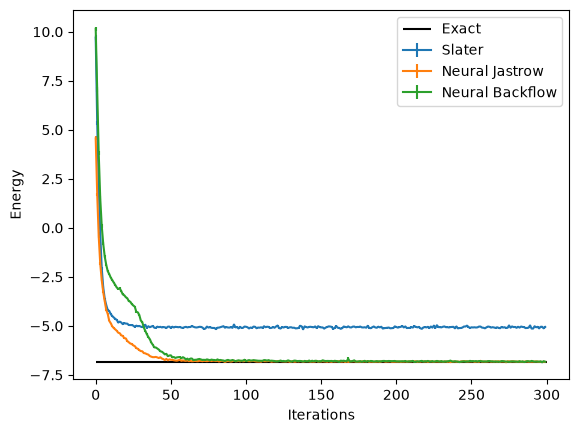

In [27]:
logged_data = (slater_log.data,nj_log.data,bf_log.data)
labels = ("Slater","Neural Jastrow","Neural Backflow")

from matplotlib import pyplot as plt

for data,label in zip(logged_data,labels):
    plt.errorbar(data["Energy"].iters, data["Energy"].Mean.real, yerr=data["Energy"].Sigma,label=label)

plt.hlines([E_gs], xmin=0, xmax=300, color='black', label="Exact")

plt.xlabel('Iterations')
plt.ylabel('Energy')
plt.legend()

## Final note: why bother with backflow?

All the Ansätze above have a clear physical motivation. However, one may wonder whether one could simply approximate the ground state of a fermionic many-body system by brute force via a more conventional neural network with sufficiently many parameters. As shown in Ref. [6], this typically leads to poor expressivity, requiring _exponentially_ many parameters to learn the sign structure of the fermionic wave function, even for trivial Hamiltonians (e.g. free fermions in two spatial dimensions). This highlights the importance of leveraging good priors in VMC.

# References

[1] Becca, F. & Sorella, S. Quantum Monte Carlo Approaches for Correlated Systems. (Cambridge University Press, 2017).

[2] Nomura, Y., Darmawan, A. S., Yamaji, Y. & Imada, M. Restricted Boltzmann machine learning for solving strongly correlated quantum systems. Phys. Rev. B 96, 205152 (2017).

[3] Stokes, J., Moreno, J. R., Pnevmatikakis, E. A. & Carleo, G. Phases of two-dimensional spinless lattice fermions with first-quantized deep neural-network quantum states. Phys. Rev. B 102, 205122 (2020).

[4] Luo, D. & Clark, B. K. Backflow Transformations via Neural Networks for Quantum Many-Body Wave Functions. Phys. Rev. Lett. 122, 226401 (2019).

[5] Tocchio, L., Becca, F. & Gros, C. Backflow correlations in the Hubbard model: An efficient tool for the study of the metal-insulator transition and the large-$U$ limit. Phys. Rev. B 83, 195138 (2011)

[6] Denis, Z., Sinibaldi, A. & Carleo, G. Comment on “Can Neural Quantum States Learn Volume-Law Ground States?” Phys. Rev. Lett. 134, 079701 (2025)